<a href="https://colab.research.google.com/github/marygizem/-Machine-Learning-and-Predictive-Analytics/blob/main/Updated%20Milestone_1_Project_Predictive_Model_BSIT_S3101_Decastillo%2C_PL_%2C_Ramos%2C_MG_%2C_Alcantara%2C_RA_%2C_Tavera%2C_RK_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Data Loading

The dataset was loaded from a pre-processed file (`merged_data.csv`) which already combines transaction, customer, and product data. This allows the analysis to focus on cleaning, feature engineering, and modeling.

In [25]:
# =========================
# 2. LOAD DATA
# =========================
merged_data = pd.read_csv("merged_data.csv")

print("Dataset loaded successfully!")
print("Shape:", merged_data.shape)
display(merged_data.head())

Dataset loaded successfully!
Shape: (5329, 12)


,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price_x,Total_Cost,Company_Name,Company_Profit,Address,Product_Name,Product_Price_y
0,2.0,29.0,19.0,16.0,2021-02-21,97930.993380,1428000.0,Sky Industries 29,61952.0,"Edsa, brgy. 606, makati, philippines!",EcoNomix Modeler,"?95,200"
1,5.0,47.0,3.0,8.0,2021-02-21,99575.609634,705600.0,Green Industries 47,31130.0,"Taft Ave, Barangay 707, Mandaluyong, Philippines",TrendWise Forecaster,"?100,800"
2,6.0,80.0,11.0,4.0,2021-07-12,160658.675350,627200.0,Green Partners 80,111227.0,"Commonwealth Ave, Barangay 202, Manila, Philip...",OptiFlow Automation,"?156,800"
3,8.0,21.0,20.0,7.0,2021-02-21,229217.941468,1792000.0,Dynamic Enterprises 21,NaN,"Ortigas Ave, Barangay 707, Davao City, Philipp...",FinSphere Intelligence Suite,"?224,000"
4,10.0,3.0,20.0,6.0,2021-02-21,238293.851303,1120000.0,Quantum Associates 3,110664.0,"Roxas Blvd, Barangay 505, Pasig, Philippines",FinSphere Intelligence Suite,"?224,000"


## Exploratory Data Analysis

This section examines the dataset structure, including data types, missing values, and summary statistics. This helps identify data quality issues and understand the distribution of variables before preprocessing.

In [27]:
# =========================
# 3. CHECK DATA INFO
# =========================
print("Dataset Info:")
merged_data.info()

print("\nMissing Values Per Column:")
print(merged_data.isna().sum())

print("\nSummary Statistics:")
display(merged_data.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5329 entries, 0 to 5328
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    5329 non-null   float64
 1   Company_ID        5329 non-null   float64
 2   Product_ID        5329 non-null   float64
 3   Quantity          5329 non-null   float64
 4   Transaction_Date  5329 non-null   object 
 5   Product_Price_x   5329 non-null   float64
 6   Total_Cost        5329 non-null   float64
 7   Company_Name      4793 non-null   object 
 8   Company_Profit    4181 non-null   float64
 9   Address           4793 non-null   object 
 10  Product_Name      4799 non-null   object 
 11  Product_Price_y   4799 non-null   object 
dtypes: float64(7), object(5)
memory usage: 499.7+ KB

Missing Values Per Column:
Transaction_ID         0
Company_ID             0
Product_ID             0
Quantity               0
Transaction_Date       0
Product_Price_

,Transaction_ID,Company_ID,Product_ID,Quantity,Product_Price_x,Total_Cost,Company_Profit
count,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5.329000e+03,4181.000000
mean,5019.826234,50.836179,10.553199,10.555639,134823.058454,1.428755e+06,76841.780914
std,2884.960700,29.101001,5.746084,5.824507,39354.618001,9.150763e+05,27032.069043
min,2.000000,1.000000,1.000000,0.000000,75613.362923,8.400000e+04,30663.000000
25%,2552.000000,25.000000,6.000000,6.000000,100431.464460,7.000000e+05,52787.000000
50%,5013.000000,51.000000,11.000000,11.000000,131074.205791,1.344000e+06,74653.000000
75%,7501.000000,77.000000,16.000000,16.000000,162487.747730,1.971200e+06,100977.000000
max,9997.000000,100.000000,20.000000,21.000000,246198.010940,4.480000e+06,118114.000000


## Data Cleaning

Missing values were handled to ensure data completeness. Numerical values such as Company Profit were filled using the median, while categorical values such as Company Name, Address, and Product Name were replaced with "Unknown". Inconsistent columns such as Product_Price_y were cleaned and removed.

In [28]:
# =========================
# 4. DATA CLEANING
# =========================
# Convert date column
merged_data["Transaction_Date"] = pd.to_datetime(merged_data["Transaction_Date"], errors="coerce")

# Fill missing values
merged_data["Company_Profit"] = merged_data["Company_Profit"].fillna(merged_data["Company_Profit"].median())
merged_data["Company_Name"] = merged_data["Company_Name"].fillna("Unknown")
merged_data["Address"] = merged_data["Address"].fillna("Unknown")
merged_data["Product_Name"] = merged_data["Product_Name"].fillna("Unknown Product")

# Clean Product_Price_y if it exists
if "Product_Price_y" in merged_data.columns:
    merged_data["Product_Price_y"] = (
        merged_data["Product_Price_y"]
        .astype(str)
        .str.replace("?", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    merged_data["Product_Price_y"] = pd.to_numeric(merged_data["Product_Price_y"], errors="coerce")

# Drop Product_Price_y if present
merged_data.drop(columns=["Product_Price_y"], inplace=True, errors="ignore")

print("\nMissing Values After Cleaning:")
print(merged_data.isna().sum())


Missing Values After Cleaning:
Transaction_ID      0
Company_ID          0
Product_ID          0
Quantity            0
Transaction_Date    0
Product_Price_x     0
Total_Cost          0
Company_Name        0
Company_Profit      0
Address             0
Product_Name        0
dtype: int64


## Feature Engineering

New features were created to enhance the dataset. Time-based features such as year, month, day of week, and quarter were extracted from the transaction date. Customer-level and product-level aggregate features were also generated to capture purchasing behavior and performance trends.

In [29]:
# =========================
# 5. FEATURE ENGINEERING
# =========================
merged_data["Transaction_Year"] = merged_data["Transaction_Date"].dt.year
merged_data["Transaction_Month"] = merged_data["Transaction_Date"].dt.month
merged_data["Transaction_DayOfWeek"] = merged_data["Transaction_Date"].dt.dayofweek
merged_data["Transaction_Quarter"] = merged_data["Transaction_Date"].dt.quarter

customer_aggregates = merged_data.groupby("Company_ID").agg(
    total_transactions=("Transaction_ID", "count"),
    total_quantity_purchased=("Quantity", "sum"),
    total_spending=("Total_Cost", "sum"),
    average_transaction_value=("Total_Cost", "mean")
).reset_index()

product_aggregates = merged_data.groupby("Product_ID").agg(
    total_quantity_sold=("Quantity", "sum"),
    total_revenue=("Total_Cost", "sum"),
    average_product_price=("Product_Price_x", "mean")
).reset_index()

merged_data = pd.merge(merged_data, customer_aggregates, on="Company_ID", how="left")
merged_data = pd.merge(merged_data, product_aggregates, on="Product_ID", how="left")

print("\nShape after feature engineering:", merged_data.shape)


Shape after feature engineering: (5329, 22)


## Handling Remaining Missing Values

Any remaining missing values were handled by filling numerical columns with their median and categorical columns with "Unknown". This ensures the dataset is complete and ready for modeling.

In [30]:
# =========================
# 6. HANDLE REMAINING NULLS
# =========================
for col in merged_data.select_dtypes(include=np.number).columns:
    merged_data[col] = merged_data[col].fillna(merged_data[col].median())

for col in merged_data.select_dtypes(include="object").columns:
    merged_data[col] = merged_data[col].fillna("Unknown")

print("\nMissing Values After Final Null Handling:")
print(merged_data.isna().sum())



Missing Values After Final Null Handling:
Transaction_ID               0
Company_ID                   0
Product_ID                   0
Quantity                     0
Transaction_Date             0
Product_Price_x              0
Total_Cost                   0
Company_Name                 0
Company_Profit               0
Address                      0
Product_Name                 0
Transaction_Year             0
Transaction_Month            0
Transaction_DayOfWeek        0
Transaction_Quarter          0
total_transactions           0
total_quantity_purchased     0
total_spending               0
average_transaction_value    0
total_quantity_sold          0
total_revenue                0
average_product_price        0
dtype: int64


## Data Preparation

Unnecessary columns such as Transaction_Date were removed since they are not directly usable in machine learning models.

In [31]:
# =========================
# 7. DROP UNUSED COLUMNS
# =========================
merged_data.drop(columns=["Transaction_Date"], inplace=True, errors="ignore")

# =========================

## Categorical Feature Encoding

Categorical variables such as Company Name, Address, and Product Name were converted into numerical format using one-hot encoding. This allows the machine learning model to process categorical data effectively.

In [32]:
# 8. ENCODE CATEGORICAL VARIABLES
# =========================
categorical_cols = merged_data.select_dtypes(include=["object"]).columns.tolist()

print("\nCategorical columns to encode:")
print(categorical_cols)

merged_data = pd.get_dummies(merged_data, columns=categorical_cols, drop_first=True)

print("\nShape after encoding:", merged_data.shape)



Categorical columns to encode:
['Company_Name', 'Address', 'Product_Name']

Shape after encoding: (5329, 213)


## Train-Test Split

The dataset was divided into features (X) and target variable (Company Profit). It was then split into training and testing sets using an 80:20 ratio to evaluate model performance on unseen data.

In [33]:
# =========================
# 9. DEFINE TARGET AND FEATURES
# =========================
target = "Company_Profit"

X = merged_data.drop(columns=[target])
y = merged_data[target]

print("\nX shape:", X.shape)
print("y shape:", y.shape)



X shape: (5329, 212)
y shape: (5329,)


In [35]:
# =========================
# 10. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)



Training set shape: (4263, 212)
Testing set shape: (1066, 212)


## Feature Scaling

Numerical features were standardized using StandardScaler to ensure that all variables are on a similar scale. This improves the performance and stability of the model.

In [36]:
# 11. SCALE FEATURES
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================

## Model Development

A Linear Regression model was implemented to predict Company Profit. The model was trained using the training dataset and learned the relationship between input features and the target variable.

In [37]:
# 12. MODEL DEVELOPMENT
# =========================
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("\nModel training completed!")


Model training completed!


In [38]:
# =========================
# 13. PREDICTIONS
# =========================
y_pred = model.predict(X_test_scaled)

# =========================

## Model Evaluation

The model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. These metrics measure prediction accuracy and how well the model explains the variance in the data.

In [40]:
# =========================
# 14. MODEL EVALUATION
# =========================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== MODEL EVALUATION =====")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)



===== MODEL EVALUATION =====
MAE: 6.298549424360662e-11
RMSE: 8.017564362886582e-11
R2 Score: 1.0


In [41]:
# =========================
# 15. ACTUAL VS PREDICTED
# =========================
results = pd.DataFrame({
    "Actual_Profit": y_test.values,
    "Predicted_Profit": y_pred
})

display(results.head(10))

# =========================

,Actual_Profit,Predicted_Profit
0,74653.0,74653.0
1,90582.0,90582.0
2,74653.0,74653.0
3,74653.0,74653.0
4,57571.0,57571.0
5,74653.0,74653.0
6,92185.0,92185.0
7,51705.0,51705.0
8,71538.0,71538.0
9,74653.0,74653.0


## Results Visualization

A scatter plot of actual versus predicted values was generated to visually assess the model's performance. A good model should show points close to the diagonal line.

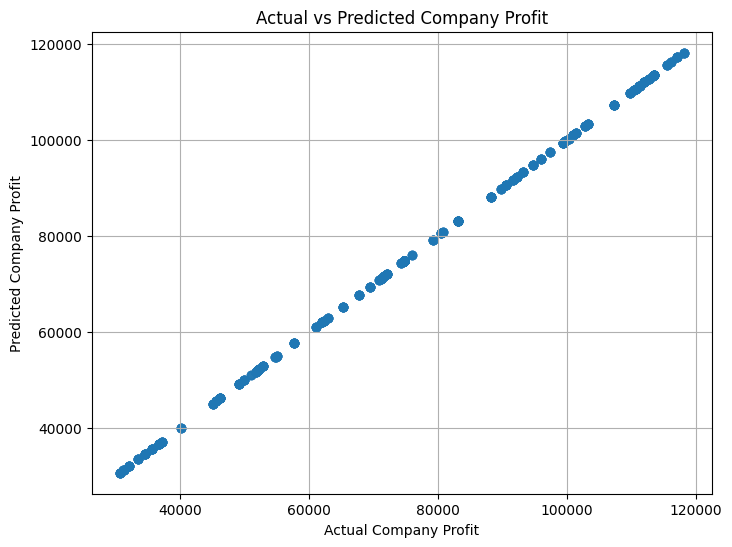

In [42]:
# 16. VISUALIZATION
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Company Profit")
plt.ylabel("Predicted Company Profit")
plt.title("Actual vs Predicted Company Profit")
plt.grid(True)
plt.show()

In [43]:
print("Model successfully trained and evaluated.")

Model successfully trained and evaluated.


SUMMARY

1. Feature Merging and Preparation:

Customer-centric aggregate features (e.g., total_transactions, total_spending,
average_transaction_value) were successfully created and merged into the main dataset using Company_ID.
Product-centric aggregate features (e.g., total_quantity_sold, total_revenue, average_product_price) were also generated and merged using Product_ID.

After feature engineering, the merged_data DataFrame was enriched with additional variables, improving its ability to capture customer behavior and product performance.

Numerical features identified include Transaction_ID, Company_ID, Product_ID, Quantity, Product_Price_x, Total_Cost, Company_Profit, time-based features, and aggregate features.
Categorical features identified include Company_Name, Address, and Product_Name.

2. Categorical Feature Encoding:

The categorical features Company_Name, Address, and Product_Name, along with temporal features (Transaction_Month, Transaction_DayOfWeek, Transaction_Quarter), were selected for encoding.

These features were transformed using one-hot encoding, resulting in an expanded dataset with additional binary columns representing each category.
The original categorical columns were removed after encoding to ensure compatibility with machine learning algorithms.

3. Numerical Feature Scaling:

All numerical features (excluding the target variable Company_Profit) were scaled using StandardScaler.

After scaling, the numerical variables were standardized with a mean close to 0 and a standard deviation close to 1, improving model performance and ensuring consistent feature contribution.

4. Model Development

A Linear Regression model was implemented to predict Company Profit. The dataset was preprocessed through data cleaning, feature engineering, encoding of categorical variables, and scaling of numerical features.

The dataset was then split into training and testing sets using an 80:20 ratio. The model was trained using the training data and used to generate predictions on the test set.

Model performance was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. This confirms that a complete predictive modeling process was successfully implemented in the analysis.